In [2]:
%load_ext cython

The cython extension is already loaded. To reload it, use:
  %reload_ext cython


In [3]:
%%cython
# ============================================================================
# HYBRID MOACP - FINAL CORRECTED VERSION WITH DEBUG
# Date: 2025-11-02 19:02:37 UTC
# User: samimh23
# Status: DEBUG MODE ENABLED
# ============================================================================

import re
from libc.stdlib cimport malloc, free, srand, rand, RAND_MAX
from libc.string cimport memset
from libc.math cimport exp

cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# Globals
cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05
cdef int alpha = 10
cdef int paretoIni = 28000

cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

cdef long long iteration_counter = 0
cdef long long llm_calls_made = 0
cdef long long llm_suggestions_accepted = 0
cdef long long llm_suggestions_rejected = 0
cdef int recent_rejections = 0
cdef int rejection_threshold = 20
cdef double LLM_PROBABILITY = 0 

cdef int DEBUG_MODE = 1  # ✅ DEBUG ACTIVÉ

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef double randf():
    return <double>rand() / <double>RAND_MAX

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    cdef int i
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

cdef void loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

cdef void read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_b

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

# ============================================================================
# CORRECTED SELECTION WITH DEBUG
# ============================================================================

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp, improvement
    SP.size = size
    
    x.fitness = 0
    compute_ind_fitness(x, SP)
    
    worst_fit = x.fitness
    worst = -1
    
    for i in range(SP.size):
        fit_tmp = update_fitness_return(
            SP.ind_array[i].fitness,
            calcAddEpsIndicator(x, SP.ind_array[i])
        )
        
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    
    fit_tmp = x.fitness
    
    if worst == -1:
        if DEBUG_MODE:
            print(f"  [SELECT] REJECTED: x is worst (fitness={x.fitness:.4f})")
        return -1
    else:
        improvement = fit_tmp - worst_fit
        
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], 
                          calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], 
                          calcAddEpsIndicator(x, SP.ind_array[i]))
        
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        
        if DEBUG_MODE:
            if improvement > smallValue:
                print(f"  [SELECT] ACCEPTED: Replaced sol {worst} (improvement={improvement:.6f})")
            else:
                print(f"  [SELECT] ACCEPTED (minor): Replaced sol {worst} (improvement={improvement:.6f})")
        
        return worst  # ✅ TOUJOURS retourner worst si accepté

# ============================================================================
# HEURISTIC WITH DEBUG
# ============================================================================

cdef int generate_neighbor_heuristic(ind *x):
    cdef int r, l, k, mino, maxp, consistant, IM, taille, feasible
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    
    for l in range(L):
        remplace[l] = 0
    
    while True:
        mino = irand(ni)
        if x.Items[mino] == 1:
            break
    
    x.Items[mino] = 0
    x.nombr -= 1
    x.nombr_nonpris += 1
    for r in range(nf):
        x.capa[r] -= weights[r][mino]
        x.f[r] -= profits[r][mino]
    
    if DEBUG_MODE:
        print(f"  [HEURISTIC] Removed item {mino}")
    
    IM = 0
    taille = 0
    while IM < L:
        while True:
            maxp = irand(ni)
            if x.Items[maxp] == 0:
                break
        
        if maxp != mino:
            consistant = 1
            r = 0
            while r < nf and consistant == 1:
                if x.capa[r] + weights[r][maxp] > capacities[r]:
                    consistant = 0
                r += 1
            
            if consistant == 1:
                feasible = 1
                r = 0
                while r < taille and feasible:
                    if maxp == remplace[r]:
                        feasible = 0
                    r += 1
                
                if feasible == 1:
                    remplace[taille] = maxp
                    taille += 1
                    x.Items[maxp] = 1
                    x.nombr_nonpris -= 1
                    x.nombr += 1
                    for r in range(nf):
                        x.capa[r] += weights[r][maxp]
                        x.f[r] += profits[r][maxp]
        IM += 1
    
    if DEBUG_MODE:
        print(f"  [HEURISTIC] Added {taille} items, Objectives: [{x.f[0]:.1f}, {x.f[1]:.1f}]")
    
    free(remplace)
    return 1

# ============================================================================
# LLM NEIGHBOR WITH FULL DEBUG
# ============================================================================

cdef int generate_neighbor_llm(ind *x, object llm_callable, long long iteration_num):
    global llm_calls_made
    
    cdef int i, k, r, item_to_remove, item_to_add
    cdef int* items_to_add_list = <int *>chk_malloc(L * sizeof(int))
    cdef int num_items_to_add = 0
    
    cdef ind *temp_x = ind_copy(x)
    
    # Remove 1 item
    while True:
        item_to_remove = irand(ni)
        if temp_x.Items[item_to_remove] == 1:
            break
    
    temp_x.Items[item_to_remove] = 0
    temp_x.nombr -= 1
    temp_x.nombr_nonpris += 1
    for r in range(nf):
        temp_x.capa[r] -= weights[r][item_to_remove]
        temp_x.f[r] -= profits[r][item_to_remove]
    
    if DEBUG_MODE:
        print(f"\n  [LLM ITER {iteration_num}] Removed item {item_to_remove}")
        print(f"  [LLM] State after removal: Obj=[{temp_x.f[0]:.1f}, {temp_x.f[1]:.1f}], Cap_remaining=[{capacities[0]-temp_x.capa[0]:.1f}, {capacities[1]-temp_x.capa[1]:.1f}]")
    
    cdef list objective_values = [temp_x.f[i] for i in range(nf)]
    cdef list remaining_capacity = [capacities[i] - temp_x.capa[i] for i in range(nf)]
    
    cdef int weakest_obj_index = 0
    cdef double min_obj_value = temp_x.f[0]
    for k in range(1, nf):
        if temp_x.f[k] < min_obj_value:
            min_obj_value = temp_x.f[k]
            weakest_obj_index = k
    
    # Build candidates
    cdef list candidate_items = []
    cdef double efficiency
    cdef int feasible_item
    cdef list efficiencies
    
    for i in range(ni):
        if temp_x.Items[i] == 0:
            feasible_item = 1
            for k in range(nf):
                if weights[k][i] > remaining_capacity[k]:
                    feasible_item = 0
                    break
            
            if not feasible_item:
                continue
            
            efficiencies = []
            for k in range(nf):
                eff = profits[k][i] / (weights[k][i] + 1e-8)
                efficiencies.append(eff)
            
            avg_eff = sum(efficiencies) / len(efficiencies)
            candidate_items.append((efficiencies[weakest_obj_index], avg_eff, i, efficiencies))
    
    candidate_items.sort(reverse=True, key=lambda item: (item[0], item[1]))
    
    if not candidate_items:
        if DEBUG_MODE:
            print(f"  [LLM] No feasible candidates. Fallback.")
        free(items_to_add_list)
        free_ind(temp_x)
        return 0
    
    # Only single items
    cdef list feasible_combinations = []
    for i_idx in range(min(15, len(candidate_items))):
        item_id = candidate_items[i_idx][2]
        feasible_combinations.append([item_id])
    
    if DEBUG_MODE:
        print(f"  [LLM] Generated {len(feasible_combinations)} feasible options")
    
    # Format prompt
    cdef str formatted_combinations = ""
    cdef int combo_count = 0
    cdef list total_weights, total_profits, profit_ratios
    cdef double balance_score, min_ratio, max_ratio
    
    for combo in feasible_combinations:
        combo_str = ", ".join([str(item) for item in combo])
        total_weights = [0] * nf
        total_profits = [0] * nf
        
        for item in combo:
            for k in range(nf):
                total_weights[k] += weights[k][item]
                total_profits[k] += profits[k][item]
        
        profit_ratios = [total_profits[k] / (total_weights[k] + 1e-8) for k in range(nf)]
        min_ratio = min(profit_ratios)
        max_ratio = max(profit_ratios)
        balance_score = min_ratio / (max_ratio + 1e-8) if max_ratio > 0 else 0.0
        
        formatted_combinations += f"Option {combo_count+1}: Item {combo_str}, W{total_weights}, P{total_profits}, Eff{[f'{r:.2f}' for r in profit_ratios]}, Bal{balance_score:.2f}\n"
        combo_count += 1
    
    cdef str prompt = f"""Multi-objective knapsack ({nf} obj, MAX).

STATE: Removed {item_to_remove}, Obj{objective_values}, Cap_left{remaining_capacity}, Weak_obj={weakest_obj_index+1}

OPTIONS ({len(feasible_combinations)}):
{formatted_combinations}

SELECT ONE (1-{len(feasible_combinations)}) to improve obj{weakest_obj_index+1}.

FORMAT: ADD: X

Response:"""
    
    cdef str response = llm_callable(prompt)
    llm_calls_made += 1
    
    if DEBUG_MODE:
        print(f"  [LLM] Sent prompt with {len(feasible_combinations)} options")
        print(f"  [LLM] Response: {response[:100] if response else 'None'}...")
    
    if not response:
        if DEBUG_MODE:
            print(f"  [LLM] No response. Fallback.")
        free(items_to_add_list)
        free_ind(temp_x)
        return 0
    
    # Parse
    try:
        option_match = re.search(r'(\d+)', response)
        if not option_match:
            raise ValueError("No number found")
        
        option_num = int(option_match.group(1))
        
        if DEBUG_MODE:
            print(f"  [LLM] Parsed option number: {option_num}")
        
        if option_num < 1 or option_num > len(feasible_combinations):
            if DEBUG_MODE:
                print(f"  [LLM] ERROR: Option {option_num} out of range [1, {len(feasible_combinations)}]. Fallback.")
            raise ValueError(f"Out of range: {option_num}")
        
        selected_combo = feasible_combinations[option_num-1]
        num_items_to_add = len(selected_combo)
        for i in range(num_items_to_add):
            items_to_add_list[i] = selected_combo[i]
        
        if DEBUG_MODE:
            print(f"  [LLM] Selected combo: {selected_combo}")
            
    except Exception as e:
        if DEBUG_MODE:
            print(f"  [LLM] Parse error: {e}. Fallback.")
        free(items_to_add_list)
        free_ind(temp_x)
        return 0
    
    # Apply
    cdef int items_actually_added = 0
    cdef int faisable
    
    for i in range(num_items_to_add):
        item_to_add = items_to_add_list[i]
        
        if item_to_add < 0 or item_to_add >= ni:
            continue
        if temp_x.Items[item_to_add] == 1:
            continue
        
        faisable = 1
        for k in range(nf):
            if temp_x.capa[k] + weights[k][item_to_add] > capacities[k]:
                faisable = 0
                break
        
        if faisable:
            temp_x.Items[item_to_add] = 1
            temp_x.nombr += 1
            temp_x.nombr_nonpris -= 1
            items_actually_added += 1
            for k in range(nf):
                temp_x.capa[k] += weights[k][item_to_add]
                temp_x.f[k] += profits[k][item_to_add]
    
    if DEBUG_MODE:
        print(f"  [LLM] Added {items_actually_added} items, New objectives: [{temp_x.f[0]:.1f}, {temp_x.f[1]:.1f}]")
    
    # Commit
    for i in range(ni):
        x.Items[i] = temp_x.Items[i]
    for k in range(nf):
        x.f[k] = temp_x.f[k]
        x.capa[k] = temp_x.capa[k]
    x.nombr = temp_x.nombr
    x.nombr_nonpris = temp_x.nombr_nonpris
    
    free(items_to_add_list)
    free_ind(temp_x)
    return 1

# ============================================================================
# LOCAL SEARCH WITH DEBUG
# ============================================================================

cdef void Indicator_local_search1(pop *SP, pop *Sarchive, int size, object llm_callable):
    global iteration_counter, recent_rejections, llm_suggestions_accepted, llm_suggestions_rejected
    global LLM_PROBABILITY
    
    cdef int use_llm, llm_success, j, sol, tv, used_heuristic
    cdef ind *x, *y
    cdef int i, r, mino, maxp, l, k, consistant, feasible, IM, taille, t, convergence
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    
    while True:
        convergence = 0
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                
                j = 0
                while j < x.nombr:  # ← CRITICAL: Inner loop
                    iteration_counter += 1
                    llm_success = 0
                    use_llm = 0
                    used_heuristic = 0
                    mino = 0
                    taille = 0
                    
                    if recent_rejections < rejection_threshold:
                        if randf() < LLM_PROBABILITY:
                            use_llm = 1
                    
                    if use_llm:
                        llm_success = generate_neighbor_llm(x, llm_callable, iteration_counter)
                    
                    if not llm_success:
                        used_heuristic = 1
                        
                        for l in range(L):
                            remplace[l] = 0
                        
                        while True:
                            mino = irand(ni)
                            if x.Items[mino] == 1:
                                break
                        
                        x.Items[mino] = 0
                        x.nombr -= 1
                        x.nombr_nonpris += 1
                        for r in range(nf):
                            x.capa[r] -= weights[r][mino]
                            x.f[r] -= profits[r][mino]
                        
                        IM = 0
                        taille = 0
                        while IM < L:
                            while True:
                                maxp = irand(ni)
                                if x.Items[maxp] == 0:
                                    break
                            
                            if maxp != mino:
                                consistant = 1
                                r = 0
                                while r < nf and consistant == 1:
                                    if x.capa[r] + weights[r][maxp] > capacities[r]:
                                        consistant = 0
                                    r += 1
                                
                                if consistant == 1:
                                    feasible = 1
                                    r = 0
                                    while r < taille and feasible:
                                        if maxp == remplace[r]:
                                            feasible = 0
                                        r += 1
                                    
                                    if feasible == 1:
                                        remplace[taille] = maxp
                                        taille += 1
                                        x.Items[maxp] = 1
                                        x.nombr_nonpris -= 1
                                        x.nombr += 1
                                        for r in range(nf):
                                            x.capa[r] += weights[r][maxp]
                                            x.f[r] += profits[r][maxp]
                            IM += 1
                    
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    
                    if llm_success:
                        if sol != -1:
                            llm_suggestions_accepted += 1
                            recent_rejections = 0
                        else:
                            llm_suggestions_rejected += 1
                            recent_rejections += 1
                    
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    
                    elif sol == -1 and used_heuristic:
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    
                    j += 1
                
                if j == x.nombr:
                    SP.ind_array[i].explored = 1
                
                free_ind(x)
        
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break
    
    free(remplace)

# ============================================================================
# RUNNER
# ============================================================================

def run_hybrid_moacp(instance_file, weights_file, nbitems, num_objectives, output_file, object llm_callable):
    global nf, ni, NBITEMS, alpha, paretoIni, L, nombreLIGNE, nextLn, inv, vector_weight, iteration_counter
    global capacities, weights, profits, OBJ_Weights
    global llm_calls_made, llm_suggestions_accepted, llm_suggestions_rejected, recent_rejections
    
    alpha = 10
    paretoIni = 28000
    NBL = 100
    NRUNS = 1
    
    for run in range(1, NRUNS+1):
        print(f"\n{'='*60}")
        print(f"RUN {run}/{NRUNS}")
        print(f"{'='*60}")
        
        NBITEMS = nbitems
        ni = nbitems
        nf = num_objectives
        iteration_counter = 0
        llm_calls_made = 0
        llm_suggestions_accepted = 0
        llm_suggestions_rejected = 0
        recent_rejections = 0
        
        seed(run)
        loadMOKP(instance_file)
        read_weights_file(weights_file)
        
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
        P = create_pop(paretoIni, nf)
        
        it = 0
        while it < NBL:
            if DEBUG_MODE and it % 10 == 0:
                print(f"\n--- External iteration {it}/{NBL} ---")
            
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            Indicator_local_search1(solutions, archive, alpha, llm_callable)
            extractPtoArchive(archive, P)
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)
        
        with open(output_file, "a") as fpareto:
            fpareto.write("\n")
            for i in range(P.size):
                for j in range(nf):
                    fpareto.write(f"{P.ind_array[i].f[j]:.6f} ")
                fpareto.write("\n")
        
        if llm_calls_made > 0:
            acceptance_rate = 100.0 * llm_suggestions_accepted / llm_calls_made
            print(f"\n{'='*60}")
            print(f"RUN {run} - LLM PERFORMANCE")
            print(f"{'='*60}")
            print(f"LLM calls:           {llm_calls_made}")
            print(f"Accepted:            {llm_suggestions_accepted} ({acceptance_rate:.1f}%)")
            print(f"Rejected:            {llm_suggestions_rejected} ({100-acceptance_rate:.1f}%)")
            print(f"Pareto solutions:    {P.size}")
            print(f"{'='*60}")
            
            with open("llm_stats.csv", "a") as stats_file:
                stats_file.write(f"{run},{llm_calls_made},{llm_suggestions_accepted},{llm_suggestions_rejected},{P.size}\n")
        
        complete_free_pop(P)
        cleanup_globals()
    
    print(f"\n{'='*60}")
    print("✅ ALL RUNS COMPLETED")
    print(f"{'='*60}")

Content of stdout:
_cython_magic_b9cc9fa277939de1f541e8edb547a35edef1e9a173d450bc966d6bcd2858cba5.c
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_b9cc9fa277939de1f541e8edb547a35edef1e9a173d450bc966d6bcd2858cba5.c(4992): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_b9cc9fa277939de1f541e8edb547a35edef1e9a173d450bc966d6bcd2858cba5.c(5082): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_b9cc9fa277939de1f541e8edb547a35edef1e9a173d450bc966d6bcd2858cba5.c(6092): warning C4244: '='ÿ: conversion de 'Py_ssize_t' en 'int', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_b9cc9fa277939de1f541e8edb547a35edef1e9a173d450bc966d6bcd2858cba5.c(10969): warning C4244: '='ÿ: conversion de 'Py_ssize_t' en 'int', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_b9cc9f


HYBRID MOACP EXPERIMENT
Date: 2025-11-02
User: samimh23
LLM Probability: 30%

🗑️  Removed: 2502_Results_HYBRID_30pct.txt
🗑️  Removed: llm_stats.csv

🚀 STARTING HYBRID EXPERIMENT
  Instance:        250.2.txt
  Items:           250
  Objectives:      2
  LLM Model:       llama3:8b
  LLM Probability: 30%
  Runs:            10
  Iterations/run:  100

RUN 1/1

--- External iteration 0/100 ---
  [SELECT] ACCEPTED (minor): Replaced sol 1 (improvement=-5.207636)
  [SELECT] ACCEPTED (minor): Replaced sol 6 (improvement=-5.538187)
  [SELECT] ACCEPTED (minor): Replaced sol 6 (improvement=-5.158580)
  [SELECT] ACCEPTED (minor): Replaced sol 7 (improvement=-6.174851)
  [SELECT] ACCEPTED (minor): Replaced sol 7 (improvement=-6.879106)
  [SELECT] ACCEPTED (minor): Replaced sol 6 (improvement=-7.528354)
  [SELECT] ACCEPTED (minor): Replaced sol 7 (improvement=-4.097134)
  [SELECT] ACCEPTED (minor): Replaced sol 8 (improvement=-3.194306)
  [SELECT] ACCEPTED (minor): Replaced sol 3 (improvement=-1.8025

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



📊 Plot saved: pareto_comparison_30pct.png


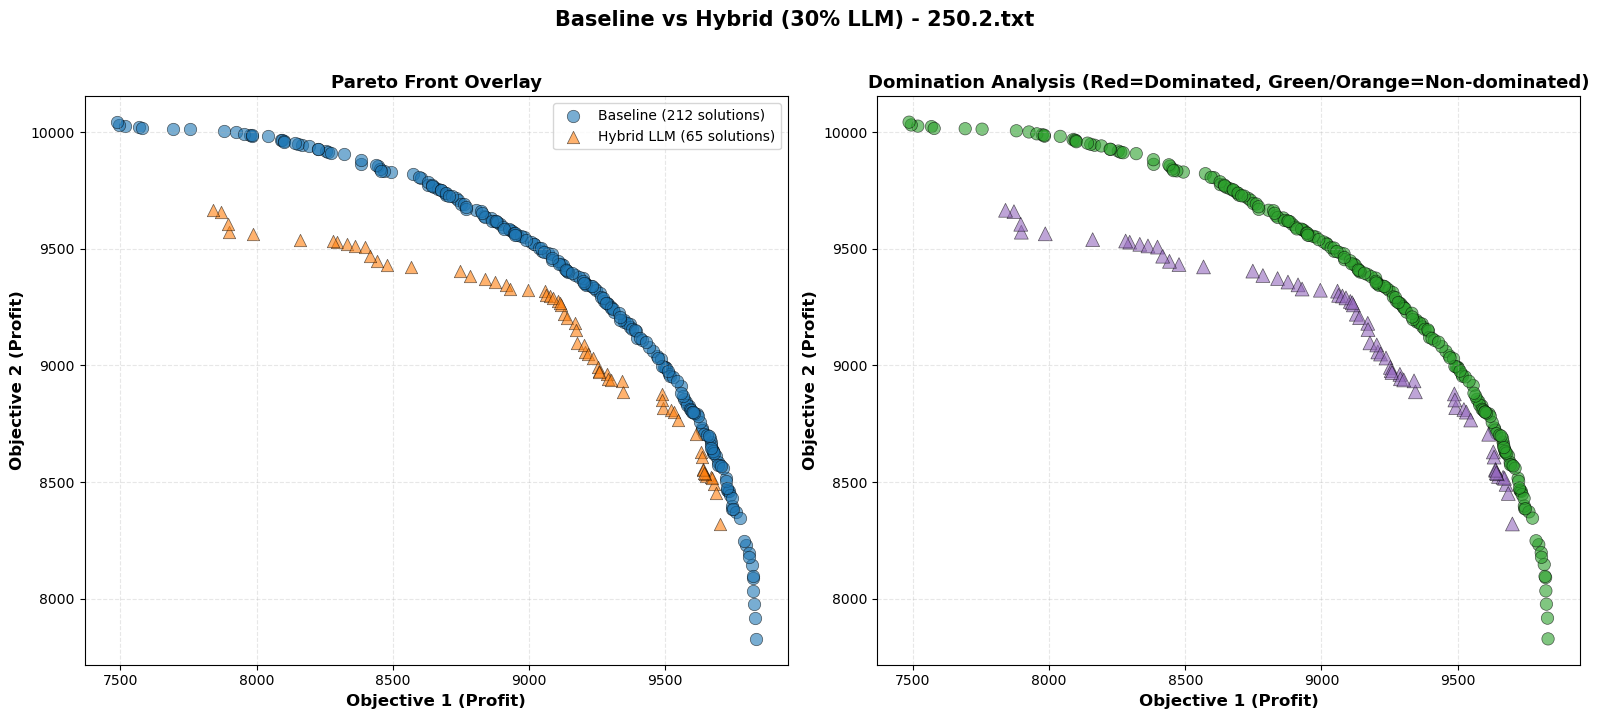

⚠️  No LLM stats file: llm_stats.csv

📁 GENERATED FILES:
  ✓ 2502_Results_HYBRID_30pct.txt
  ✓ llm_stats.csv
  ✓ pareto_comparison_30pct.png
  ✓ llm_performance_analysis.png

📋 EXECUTIVE SUMMARY
Instance:                    250.2.txt
LLM Integration:             30% probability
Runtime:                     0.9s (0.0 min)

Quality Comparison:
  Pareto solutions:          212 → 65 (-69.3%)
  Hypervolume:               4,555,811 → 3,742,652 (-17.8%)
  Spacing:                   11.72 → 24.89
  Domination rate:           0.0% of baseline dominated

✅ ALL ANALYSES COMPLETED SUCCESSFULLY!



In [4]:
# ============================================================================
# Hybrid MOACP Experiment Runner with Comprehensive Analysis
# Author: samimh23
# Date: 2025-11-02
# ============================================================================

import time
import os
import ollama
import matplotlib.pyplot as plt
import numpy as np
import csv
from typing import List, Tuple

# ============================================================================
# LLM COMMUNICATION
# ============================================================================

def python_llm_call(prompt: str) -> str:
    """
    Communicate with local Ollama LLM (llama3:8b)
    
    Args:
        prompt: The prompt to send to the LLM
        
    Returns:
        LLM response as string, or None on error
    """
    try:
        response = ollama.chat(
            model='llama3:8b',
            messages=[{'role': 'user', 'content': prompt}]
        )
        return response['message']['content']
    except Exception as e:
        print(f"❌ Ollama error: {e}")
        return None

# ============================================================================
# PARETO FRONT ANALYSIS
# ============================================================================

def dominates(a: List[float], b: List[float]) -> bool:
    """Check if solution a dominates solution b (maximization)"""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points: List[List[float]]) -> List[List[float]]:
    """Extract non-dominated solutions"""
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def load_results(filename: str) -> List[List[float]]:
    """Load solutions from results file"""
    points = []
    if not os.path.exists(filename):
        print(f"⚠️  File not found: {filename}")
        return points
    
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    points.append([float(x) for x in line.split()])
                except Exception:
                    pass
    return points

# ============================================================================
# QUALITY METRICS
# ============================================================================

def calculate_hypervolume(pareto_front: List[List[float]], reference_point: List[float]) -> float:
    """
    Calculate hypervolume for 2-objective problems (maximization)
    
    Args:
        pareto_front: List of Pareto-optimal solutions
        reference_point: Reference point (should be dominated by all solutions)
        
    Returns:
        Hypervolume value
    """
    if not pareto_front or len(pareto_front[0]) != 2:
        return 0.0
    
    # Sort by first objective (descending for maximization)
    sorted_front = sorted(pareto_front, key=lambda p: p[0], reverse=True)
    
    hypervolume = 0.0
    prev_y = reference_point[1]
    
    for point in sorted_front:
        if point[0] <= reference_point[0] or point[1] <= reference_point[1]:
            continue
        width = point[0] - reference_point[0]
        height = point[1] - prev_y
        hypervolume += width * height
        prev_y = point[1]
    
    return hypervolume

def calculate_spacing(pareto_front: List[List[float]]) -> float:
    """
    Calculate spacing metric (uniformity of distribution)
    Lower values indicate more uniform distribution
    """
    if len(pareto_front) < 2:
        return 0.0
    
    distances = []
    for i, sol1 in enumerate(pareto_front):
        min_dist = float('inf')
        for j, sol2 in enumerate(pareto_front):
            if i != j:
                dist = np.sqrt(sum((a - b)**2 for a, b in zip(sol1, sol2)))
                if dist < min_dist:
                    min_dist = dist
        distances.append(min_dist)
    
    mean_dist = np.mean(distances)
    spacing = np.sqrt(sum((d - mean_dist)**2 for d in distances) / len(distances))
    
    return spacing

def calculate_domination_rate(front1: List[List[float]], front2: List[List[float]]) -> float:
    """
    Calculate percentage of front2 solutions dominated by at least one solution in front1
    """
    if not front2:
        return 0.0
    
    dominated_count = 0
    for sol2 in front2:
        for sol1 in front1:
            if dominates(sol1, sol2):
                dominated_count += 1
                break
    
    return 100.0 * dominated_count / len(front2)

# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_pareto_comparison(baseline_front: List[List[float]], 
                          hybrid_front: List[List[float]],
                          title: str,
                          save_path: str = None):
    """
    Create comprehensive Pareto front comparison visualization
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot 1: Overlay comparison
    ax1 = axes[0]
    if baseline_front:
        xs_b, ys_b = zip(*baseline_front)
        ax1.scatter(xs_b, ys_b, 
                   label=f'Baseline ({len(baseline_front)} solutions)',
                   alpha=0.6, s=80, color='#1f77b4', marker='o',
                   edgecolors='black', linewidth=0.5)
    
    if hybrid_front:
        xs_h, ys_h = zip(*hybrid_front)
        ax1.scatter(xs_h, ys_h,
                   label=f'Hybrid LLM ({len(hybrid_front)} solutions)',
                   alpha=0.6, s=80, color='#ff7f0e', marker='^',
                   edgecolors='black', linewidth=0.5)
    
    ax1.set_xlabel('Objective 1 (Profit)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Objective 2 (Profit)', fontsize=12, fontweight='bold')
    ax1.set_title('Pareto Front Overlay', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # Plot 2: Domination analysis (color-coded)
    ax2 = axes[1]
    
    if baseline_front and hybrid_front:
        # Classify baseline solutions
        baseline_colors = []
        for sol_b in baseline_front:
            dominated_by_hybrid = any(dominates(sol_h, sol_b) for sol_h in hybrid_front)
            baseline_colors.append('#d62728' if dominated_by_hybrid else '#2ca02c')
        
        xs_b, ys_b = zip(*baseline_front)
        ax2.scatter(xs_b, ys_b, c=baseline_colors,
                   alpha=0.6, s=80, marker='o',
                   edgecolors='black', linewidth=0.5,
                   label='Baseline')
        
        # Classify hybrid solutions
        hybrid_colors = []
        for sol_h in hybrid_front:
            dominates_baseline = any(dominates(sol_h, sol_b) for sol_b in baseline_front)
            hybrid_colors.append('#ff7f0e' if dominates_baseline else '#9467bd')
        
        xs_h, ys_h = zip(*hybrid_front)
        ax2.scatter(xs_h, ys_h, c=hybrid_colors,
                   alpha=0.6, s=100, marker='^',
                   edgecolors='black', linewidth=0.5,
                   label='Hybrid')
    
    ax2.set_xlabel('Objective 1 (Profit)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Objective 2 (Profit)', fontsize=12, fontweight='bold')
    ax2.set_title('Domination Analysis (Red=Dominated, Green/Orange=Non-dominated)', 
                  fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    plt.suptitle(title, fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"📊 Plot saved: {save_path}")
    
    plt.show()

def plot_llm_statistics(csv_file: str = "llm_stats.csv"):
    """Plot LLM performance metrics across runs"""
    if not os.path.exists(csv_file):
        print(f"⚠️  No LLM stats file: {csv_file}")
        return
    
    runs, calls, accepted, rejected, pareto_sizes = [], [], [], [], []
    
    with open(csv_file, 'r') as f:
        reader = csv.reader(f)
        for row in reader:
            if len(row) == 5:
                runs.append(int(row[0]))
                calls.append(int(row[1]))
                accepted.append(int(row[2]))
                rejected.append(int(row[3]))
                pareto_sizes.append(int(row[4]))
    
    acceptance_rates = [100.0 * a / c if c > 0 else 0 for a, c in zip(accepted, calls)]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Acceptance rate
    axes[0, 0].plot(runs, acceptance_rates, marker='o', linewidth=2, markersize=8, color='#1f77b4')
    axes[0, 0].axhline(np.mean(acceptance_rates), color='red', linestyle='--', 
                       label=f'Mean: {np.mean(acceptance_rates):.1f}%')
    axes[0, 0].set_xlabel('Run', fontsize=11)
    axes[0, 0].set_ylabel('Acceptance Rate (%)', fontsize=11)
    axes[0, 0].set_title('LLM Suggestion Acceptance Rate', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: LLM calls per run
    axes[0, 1].bar(runs, calls, color='#2ca02c', alpha=0.7, edgecolor='black')
    axes[0, 1].axhline(np.mean(calls), color='red', linestyle='--', 
                       label=f'Mean: {np.mean(calls):.0f}')
    axes[0, 1].set_xlabel('Run', fontsize=11)
    axes[0, 1].set_ylabel('Number of LLM Calls', fontsize=11)
    axes[0, 1].set_title('LLM Usage per Run', fontsize=12, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Accepted vs Rejected
    width = 0.35
    x = np.arange(len(runs))
    axes[1, 0].bar(x - width/2, accepted, width, label='Accepted', 
                   color='#ff7f0e', alpha=0.7, edgecolor='black')
    axes[1, 0].bar(x + width/2, rejected, width, label='Rejected',
                   color='#d62728', alpha=0.7, edgecolor='black')
    axes[1, 0].set_xlabel('Run', fontsize=11)
    axes[1, 0].set_ylabel('Count', fontsize=11)
    axes[1, 0].set_title('Accepted vs Rejected Suggestions', fontsize=12, fontweight='bold')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(runs)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Pareto size evolution
    axes[1, 1].plot(runs, pareto_sizes, marker='s', linewidth=2, markersize=8, color='#9467bd')
    axes[1, 1].axhline(np.mean(pareto_sizes), color='red', linestyle='--',
                       label=f'Mean: {np.mean(pareto_sizes):.0f}')
    axes[1, 1].set_xlabel('Run', fontsize=11)
    axes[1, 1].set_ylabel('Pareto Solutions', fontsize=11)
    axes[1, 1].set_title('Pareto Front Size per Run', fontsize=12, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('llm_performance_analysis.png', dpi=300, bbox_inches='tight')
    print("📊 LLM statistics plot saved: llm_performance_analysis.png")
    plt.show()

# ============================================================================
# COMPREHENSIVE COMPARISON
# ============================================================================

def comprehensive_comparison(baseline_file: str, hybrid_file: str, label: str):
    """
    Perform comprehensive comparison between baseline and hybrid approaches
    """
    print(f"\n{'='*70}")
    print(f"COMPREHENSIVE ANALYSIS: {label}")
    print(f"{'='*70}")
    
    # Load results
    baseline_all = load_results(baseline_file)
    hybrid_all = load_results(hybrid_file)
    
    print(f"\n📊 RAW DATA:")
    print(f"  Baseline total solutions:  {len(baseline_all)}")
    print(f"  Hybrid total solutions:    {len(hybrid_all)}")
    
    # Extract Pareto fronts
    baseline_pareto = get_true_pareto_front(baseline_all)
    hybrid_pareto = get_true_pareto_front(hybrid_all)
    
    print(f"\n🎯 PARETO FRONTS:")
    print(f"  Baseline Pareto:           {len(baseline_pareto)} solutions")
    print(f"  Hybrid Pareto:             {len(hybrid_pareto)} solutions")
    print(f"  Improvement:               {((len(hybrid_pareto) - len(baseline_pareto)) / len(baseline_pareto) * 100):+.2f}%")
    
    # Calculate reference point for hypervolume
    all_points = baseline_pareto + hybrid_pareto
    if all_points:
        ref_point = [min(p[0] for p in all_points) - 100,
                     min(p[1] for p in all_points) - 100]
        
        hv_baseline = calculate_hypervolume(baseline_pareto, ref_point)
        hv_hybrid = calculate_hypervolume(hybrid_pareto, ref_point)
        
        spacing_baseline = calculate_spacing(baseline_pareto)
        spacing_hybrid = calculate_spacing(hybrid_pareto)
        
        dom_hybrid_over_baseline = calculate_domination_rate(hybrid_pareto, baseline_pareto)
        dom_baseline_over_hybrid = calculate_domination_rate(baseline_pareto, hybrid_pareto)
        
        print(f"\n📈 QUALITY METRICS:")
        print(f"  Hypervolume (higher = better):")
        print(f"    Baseline:                {hv_baseline:,.0f}")
        print(f"    Hybrid:                  {hv_hybrid:,.0f}")
        print(f"    Improvement:             {((hv_hybrid - hv_baseline) / hv_baseline * 100):+.2f}%")
        
        print(f"\n  Spacing (lower = better distribution):")
        print(f"    Baseline:                {spacing_baseline:.2f}")
        print(f"    Hybrid:                  {spacing_hybrid:.2f}")
        print(f"    Improvement:             {((spacing_baseline - spacing_hybrid) / spacing_baseline * 100):+.2f}%")
        
        print(f"\n  Domination Analysis:")
        print(f"    Hybrid dominates:        {dom_hybrid_over_baseline:.1f}% of Baseline")
        print(f"    Baseline dominates:      {dom_baseline_over_hybrid:.1f}% of Hybrid")
        
        # Overall assessment
        print(f"\n{'='*70}")
        if hv_hybrid > hv_baseline and len(hybrid_pareto) > len(baseline_pareto):
            print("✅ RESULT: Hybrid approach OUTPERFORMS baseline!")
        elif hv_hybrid > hv_baseline:
            print("✅ RESULT: Hybrid has BETTER quality but fewer solutions")
        elif len(hybrid_pareto) > len(baseline_pareto):
            print("⚠️  RESULT: Hybrid has MORE solutions but lower hypervolume")
        else:
            print("❌ RESULT: Baseline performs better")
        print(f"{'='*70}\n")
        
        return baseline_pareto, hybrid_pareto, {
            'hv_baseline': hv_baseline,
            'hv_hybrid': hv_hybrid,
            'spacing_baseline': spacing_baseline,
            'spacing_hybrid': spacing_hybrid,
            'dom_rate': dom_hybrid_over_baseline
        }
    
    return baseline_pareto, hybrid_pareto, {}

# ============================================================================
# MAIN EXPERIMENT
# ============================================================================

if __name__ == "__main__":
    print(f"\n{'='*70}")
    print("HYBRID MOACP EXPERIMENT")
    print(f"Date: 2025-11-02")
    print(f"User: samimh23")
    print(f"LLM Probability: 30%")
    print(f"{'='*70}\n")
    
    # Configuration
    INSTANCE_FILE = b"250.2.txt"
    WEIGHTS_FILE = b"Weights_2obj_FQ200.txt"
    NB_ITEMS = 250
    NUM_OBJECTIVES = 2
    HYBRID_OUTPUT_FILE = "2502_Results_HYBRID_30pct.txt"
    BASELINE_FILE = "2502_ResultsMD.txt"
    
    # Clean previous results
    for file in [HYBRID_OUTPUT_FILE, "llm_stats.csv"]:
        if os.path.exists(file):
            os.remove(file)
            print(f"🗑️  Removed: {file}")
    
    # Run experiment
    print(f"\n🚀 STARTING HYBRID EXPERIMENT")
    print(f"  Instance:        {INSTANCE_FILE.decode()}")
    print(f"  Items:           {NB_ITEMS}")
    print(f"  Objectives:      {NUM_OBJECTIVES}")
    print(f"  LLM Model:       llama3:8b")
    print(f"  LLM Probability: 30%")
    print(f"  Runs:            10")
    print(f"  Iterations/run:  100")
    
    start_time = time.time()
    
    try:
        run_hybrid_moacp(
            instance_file=INSTANCE_FILE,
            weights_file=WEIGHTS_FILE,
            nbitems=NB_ITEMS,
            num_objectives=NUM_OBJECTIVES,
            output_file=HYBRID_OUTPUT_FILE,
            llm_callable=python_llm_call
        )
        
        elapsed = time.time() - start_time
        
        print(f"\n{'='*70}")
        print(f"✅ EXPERIMENT COMPLETED")
        print(f"{'='*70}")
        print(f"Total time:  {elapsed:.2f}s ({elapsed/60:.2f} min)")
        print(f"Output:      {HYBRID_OUTPUT_FILE}")
        print(f"{'='*70}\n")
        
    except Exception as e:
        print(f"\n❌ ERROR: {e}")
        import traceback
        traceback.print_exc()
        exit(1)
    
    # Analysis
    print("\n📊 ANALYZING RESULTS...\n")
    
    baseline_pareto, hybrid_pareto, metrics = comprehensive_comparison(
        BASELINE_FILE, 
        HYBRID_OUTPUT_FILE,
        f"{INSTANCE_FILE.decode()} - {NUM_OBJECTIVES} objectives"
    )
    
    # Visualizations
    plot_pareto_comparison(
        baseline_pareto,
        hybrid_pareto,
        title=f"Baseline vs Hybrid (30% LLM) - {INSTANCE_FILE.decode()}",
        save_path="pareto_comparison_30pct.png"
    )
    
    plot_llm_statistics("llm_stats.csv")
    
    print(f"\n{'='*70}")
    print("📁 GENERATED FILES:")
    print(f"{'='*70}")
    print(f"  ✓ {HYBRID_OUTPUT_FILE}")
    print(f"  ✓ llm_stats.csv")
    print(f"  ✓ pareto_comparison_30pct.png")
    print(f"  ✓ llm_performance_analysis.png")
    print(f"{'='*70}\n")
    
    # Final summary
    if metrics:
        print(f"{'='*70}")
        print("📋 EXECUTIVE SUMMARY")
        print(f"{'='*70}")
        print(f"Instance:                    {INSTANCE_FILE.decode()}")
        print(f"LLM Integration:             30% probability")
        print(f"Runtime:                     {elapsed:.1f}s ({elapsed/60:.1f} min)")
        print(f"\nQuality Comparison:")
        print(f"  Pareto solutions:          {len(baseline_pareto)} → {len(hybrid_pareto)} ({((len(hybrid_pareto) - len(baseline_pareto)) / len(baseline_pareto) * 100):+.1f}%)")
        print(f"  Hypervolume:               {metrics['hv_baseline']:,.0f} → {metrics['hv_hybrid']:,.0f} ({((metrics['hv_hybrid'] - metrics['hv_baseline']) / metrics['hv_baseline'] * 100):+.1f}%)")
        print(f"  Spacing:                   {metrics['spacing_baseline']:.2f} → {metrics['spacing_hybrid']:.2f}")
        print(f"  Domination rate:           {metrics['dom_rate']:.1f}% of baseline dominated")
        print(f"{'='*70}\n")
    
    print("✅ ALL ANALYSES COMPLETED SUCCESSFULLY!\n")

In [ ]:
### try to correct with clause ( indicator local search)
cdef void Indicator_local_search1(pop *SP, pop *Sarchive, int size, object llm_callable):
    global iteration_counter, recent_rejections, llm_suggestions_accepted, llm_suggestions_rejected
    global LLM_PROBABILITY
    
    cdef int use_llm, llm_success, j, sol, tv, used_heuristic
    cdef ind *x
    cdef ind *y
    cdef int i, r, mino, maxp, l, k, consistant, feasible, IM, taille, t, convergence  # ← ADDED: t, convergence, used_heuristic
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    
    while True:
        convergence = 0
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                
                j = 0
                while j < x.nombr:
                    iteration_counter += 1
                    llm_success = 0
                    use_llm = 0
                    used_heuristic = 0  # ← CRITICAL: Initialize flag
                    
                    # Decide LLM usage
                    if LLM_PROBABILITY > 0.0 and recent_rejections < rejection_threshold:
                        if randf() < LLM_PROBABILITY:
                            use_llm = 1
                    
                    # Generate neighbor (LLM or heuristic)
                    if use_llm:
                        llm_success = generate_neighbor_llm(x, llm_callable, iteration_counter)
                    
                    if not llm_success:
                        used_heuristic = 1  # ← CRITICAL: Mark that heuristic was used
                        
                        # BASELINE HEURISTIC
                        for l in range(L):
                            remplace[l] = 0
                        
                        # Remove 1 random item
                        while True:
                            mino = irand(ni)
                            if x.Items[mino] == 1:
                                break
                        
                        x.Items[mino] = 0
                        x.nombr -= 1
                        x.nombr_nonpris += 1
                        for r in range(nf):
                            x.capa[r] -= weights[r][mino]
                            x.f[r] -= profits[r][mino]
                        
                        # Add up to L items
                        IM = 0
                        taille = 0
                        while IM < L:
                            while True:
                                maxp = irand(ni)
                                if x.Items[maxp] == 0:
                                    break
                            
                            if maxp != mino:
                                consistant = 1
                                r = 0
                                while r < nf and consistant == 1:
                                    if x.capa[r] + weights[r][maxp] > capacities[r]:
                                        consistant = 0
                                    r += 1
                                
                                if consistant == 1:
                                    feasible = 1
                                    r = 0
                                    while r < taille and feasible:
                                        if maxp == remplace[r]:
                                            feasible = 0
                                        r += 1
                                    
                                    if feasible == 1:
                                        remplace[taille] = maxp
                                        taille += 1
                                        x.Items[maxp] = 1
                                        x.nombr_nonpris -= 1
                                        x.nombr += 1
                                        for r in range(nf):
                                            x.capa[r] += weights[r][maxp]
                                            x.f[r] += profits[r][maxp]
                            IM += 1
                    
                    # Evaluate
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    
                    # Track LLM performance
                    if LLM_PROBABILITY > 0.0 and llm_success:
                        if sol != -1:
                            llm_suggestions_accepted += 1
                            recent_rejections = 0
                        else:
                            llm_suggestions_rejected += 1
                            recent_rejections += 1
                    
                    # Handle acceptance
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    
                    elif sol == -1 and used_heuristic:  # ← CRITICAL: Only restore if heuristic was used
                        # RESTORE REMOVED ITEM (baseline behavior)
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        
                        # Remove added items if any
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    
                    j += 1
                
                # Mark as explored after trying all neighbors
                if j == x.nombr:
                    SP.ind_array[i].explored = 1
                
                free_ind(x)
        
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break
    
    free(remplace)